<a href="https://colab.research.google.com/github/busraparlakk/Auto-MPG/blob/main/K%C3%BCresel_%C3%87ay_ve_Kahve_Ya%C5%9Fam_Tarz%C4%B1_Veri_Setine_knn_uygulamas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
df = pd.read_csv("/content/tea_vs_coffee_global_final.csv")

df.head()

In [14]:
df.columns.tolist()

['country',
 'continent',
 'year',
 'age',
 'gender',
 'income_level',
 'drink_preference',
 'favorite_drink',
 'drink_category',
 'cups_per_day',
 'drink_temperature',
 'sugar_level',
 'milk_usage',
 'caffeine_preference',
 'taste_score',
 'bitterness',
 'acidity',
 'aroma_score',
 'monthly_spend',
 'price_per_cup',
 'home_vs_cafe_ratio',
 'work_type',
 'sleep_hours',
 'stress_level',
 'exercise_frequency',
 'bmi',
 'hydration_level',
 'heart_rate',
 'drink_reason',
 'social_setting',
 'time_of_day',
 'loyalty_brand',
 'experiment_new_drinks',
 'satisfaction_level']

In [ ]:
df.isnull().sum()

In [ ]:
df = df.dropna()

In [ ]:
df.columns

In [15]:
target = "drink_preference"

In [16]:
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

,country,continent,year,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
0,1,2,2015,56,1,1,0,13,0,2.3,...,2,26.9,9,86,3,3,0,1,0,3
1,1,2,2015,61,2,0,1,14,1,1.3,...,0,20.9,1,95,1,1,3,1,0,6
2,1,2,2015,59,0,1,0,0,0,3.2,...,1,31.6,1,84,3,0,3,0,0,8
3,1,2,2015,41,2,0,0,2,0,3.0,...,2,33.1,1,94,0,3,0,0,1,5
4,1,2,2015,43,2,2,1,7,1,1.9,...,0,29.8,2,65,2,1,3,1,0,7


In [17]:
X = df.drop(target, axis=1)
y = df[target]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
y_pred = knn.predict(X_test)

In [22]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1402   65]
 [  40 1493]]


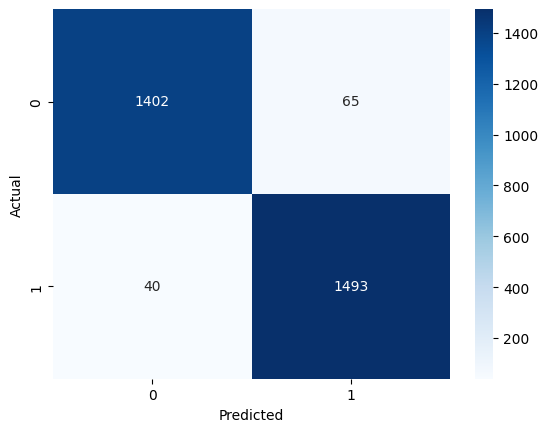

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.965


In [25]:
df.columns.tolist()

['country',
 'continent',
 'year',
 'age',
 'gender',
 'income_level',
 'drink_preference',
 'favorite_drink',
 'drink_category',
 'cups_per_day',
 'drink_temperature',
 'sugar_level',
 'milk_usage',
 'caffeine_preference',
 'taste_score',
 'bitterness',
 'acidity',
 'aroma_score',
 'monthly_spend',
 'price_per_cup',
 'home_vs_cafe_ratio',
 'work_type',
 'sleep_hours',
 'stress_level',
 'exercise_frequency',
 'bmi',
 'hydration_level',
 'heart_rate',
 'drink_reason',
 'social_setting',
 'time_of_day',
 'loyalty_brand',
 'experiment_new_drinks',
 'satisfaction_level']